# 🔮 WORD ORACLE — AI-Powered Word Guessing Game

> **Advanced ML Project** | Semantic Similarity · NLP · Neural Embeddings · Interactive UI

---

### Features
- **Semantic Similarity Engine** using TF-IDF + cosine similarity
- **Word Embeddings** via `gensim` Word2Vec / GloVe-style vectors
- **Heat Meter** — live semantic distance feedback
- **Multiple Game Modes**: Classic, Hardcore, Blitz
- **Adaptive Difficulty** — AI selects harder words as you improve
- **Leaderboard** with persistent score tracking
- **Rich Terminal UI** using `ipywidgets` + `IPython.display`


## Install Dependencies

In [ ]:
# ─── INSTALL ALL REQUIRED PACKAGES ───────────────────────────────────────────
import subprocess, sys

packages = [
    'ipywidgets',
    'gensim',
    'nltk',
    'scikit-learn',
    'numpy',
    'pandas',
    'matplotlib',
    'rich',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed successfully!')

## Imports & NLTK Data

In [19]:
# ─── IMPORTS ──────────────────────────────────────────────────────────────────
import random
import time
import json
import math
import re
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download NLTK data
for resource in ['wordnet', 'punkt', 'averaged_perceptron_tagger', 'omw-1.4']:
    try:
        nltk.download(resource, quiet=True)
    except:
        pass

print('✅ All imports successful!')

✅ All imports successful!


## ML Core: Semantic Similarity Engine

In [20]:
# ─── SEMANTIC SIMILARITY ENGINE ───────────────────────────────────────────────
# Multi-strategy similarity: character n-grams + WordNet synsets + TF-IDF

class SemanticEngine:
    """
    Multi-strategy semantic similarity engine combining:
    1. Character-level n-gram Jaccard similarity
    2. WordNet synset path similarity
    3. Edit distance (Levenshtein) normalized score
    4. Phonetic similarity (Soundex-inspired)
    """

    def __init__(self):
        self.tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2, 4))
        self._corpus_fitted = False

    # ── N-gram Jaccard ────────────────────────────────────────────────────────
    def _ngram_jaccard(self, a: str, b: str, n: int = 2) -> float:
        def ngrams(s, n):
            return set(s[i:i+n] for i in range(len(s)-n+1))
        A, B = ngrams(a, n), ngrams(b, n)
        if not A or not B:
            return 0.0
        return len(A & B) / len(A | B)

    # ── Levenshtein Edit Distance ─────────────────────────────────────────────
    def _edit_distance_sim(self, a: str, b: str) -> float:
        m, n = len(a), len(b)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(m+1): dp[i][0] = i
        for j in range(n+1): dp[0][j] = j
        for i in range(1, m+1):
            for j in range(1, n+1):
                cost = 0 if a[i-1]==b[j-1] else 1
                dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
        dist = dp[m][n]
        return 1.0 - dist / max(m, n)

    # ── WordNet Synset Similarity ─────────────────────────────────────────────
    def _wordnet_sim(self, a: str, b: str) -> float:
        try:
            synsets_a = wordnet.synsets(a)
            synsets_b = wordnet.synsets(b)
            if not synsets_a or not synsets_b:
                return 0.0
            best = 0.0
            for sa in synsets_a[:3]:
                for sb in synsets_b[:3]:
                    try:
                        score = sa.path_similarity(sb) or 0.0
                        best = max(best, score)
                    except:
                        pass
            return best
        except:
            return 0.0

    # ── TF-IDF Character Cosine ───────────────────────────────────────────────
    def _tfidf_sim(self, a: str, b: str) -> float:
        try:
            matrix = self.tfidf.fit_transform([a, b])
            return float(cosine_similarity(matrix[0], matrix[1])[0][0])
        except:
            return 0.0

    # ── Letter Position Overlap ───────────────────────────────────────────────
    def _positional_overlap(self, guess: str, target: str) -> float:
        matches = sum(1 for i, c in enumerate(guess) if i < len(target) and c == target[i])
        return matches / max(len(guess), len(target))

    # ── MAIN SCORER ───────────────────────────────────────────────────────────
    def score(self, guess: str, target: str) -> dict:
        """Returns a rich similarity dict with component scores and final sim."""
        g, t = guess.lower().strip(), target.lower().strip()

        if g == t:
            return {
                'total': 1.0, 'ngram2': 1.0, 'ngram3': 1.0,
                'edit': 1.0, 'wordnet': 1.0, 'tfidf': 1.0,
                'positional': 1.0, 'exact': True
            }

        ng2   = self._ngram_jaccard(g, t, 2)
        ng3   = self._ngram_jaccard(g, t, 3)
        edit  = self._edit_distance_sim(g, t)
        wn    = self._wordnet_sim(g, t)
        tfidf = self._tfidf_sim(g, t)
        pos   = self._positional_overlap(g, t)

        # Weighted combination — WordNet carries the most semantic weight
        total = (
            ng2   * 0.18 +
            ng3   * 0.14 +
            edit  * 0.18 +
            wn    * 0.30 +
            tfidf * 0.12 +
            pos   * 0.08
        )
        # Small bonus if first letter matches
        if g and t and g[0] == t[0]:
            total = min(1.0, total + 0.05)

        return {
            'total': round(min(total, 0.97), 4),
            'ngram2': round(ng2, 4),
            'ngram3': round(ng3, 4),
            'edit': round(edit, 4),
            'wordnet': round(wn, 4),
            'tfidf': round(tfidf, 4),
            'positional': round(pos, 4),
            'exact': False
        }

    def heat_label(self, sim: float) -> tuple:
        """Returns (emoji, label, color) for the similarity score."""
        if sim >= 0.85: return ('🔥', 'ON FIRE',   '#ff4757')
        if sim >= 0.65: return ('♨️',  'HOT',       '#ffa502')
        if sim >= 0.40: return ('🌡️',  'WARM',      '#eccc68')
        if sim >= 0.20: return ('💧', 'COOL',      '#70a1ff')
        return              ('❄️',  'FREEZING',  '#74b9ff')


# Instantiate the engine
engine = SemanticEngine()

# Quick smoke test
test = engine.score('ocean', 'sea')
print(f"Similarity test 'ocean' vs 'sea': {test['total']:.2%}")
test2 = engine.score('apple', 'fruit')
print(f"Similarity test 'apple' vs 'fruit': {test2['total']:.2%}")
print(f"\n🔬 Component breakdown (ocean vs sea):")
for k, v in test.items():
    if k not in ('exact', 'total'):
        print(f"   {k:12s}: {v:.4f}")
print(f"\n✅ Semantic Engine ready!")

Similarity test 'ocean' vs 'sea': 42.12%
Similarity test 'apple' vs 'fruit': 10.00%

🔬 Component breakdown (ocean vs sea):
   ngram2      : 0.2000
   ngram3      : 0.0000
   edit        : 0.4000
   wordnet     : 1.0000
   tfidf       : 0.1096
   positional  : 0.0000

✅ Semantic Engine ready!


## Word Database & Adaptive Difficulty

In [21]:
# ─── WORD DATABASE ────────────────────────────────────────────────────────────

WORD_DB = {
    'easy': [
        {'word': 'apple',   'category': 'Fruit',        'hint': 'Keeps the doctor away', 'clue': 'Red or green, it grows on trees'},
        {'word': 'beach',   'category': 'Nature',       'hint': 'Sandy shore by the sea', 'clue': 'Waves crash here under the sun'},
        {'word': 'cloud',   'category': 'Weather',      'hint': 'Floats in the sky', 'clue': 'White puffs that bring rain'},
        {'word': 'dance',   'category': 'Activity',     'hint': 'Move rhythmically to music', 'clue': 'Expression through body movement'},
        {'word': 'eagle',   'category': 'Animal',       'hint': 'Majestic bird of prey', 'clue': 'Symbol of freedom with sharp talons'},
        {'word': 'flame',   'category': 'Fire',         'hint': 'Product of combustion', 'clue': 'Bright and hot, it flickers'},
        {'word': 'grape',   'category': 'Fruit',        'hint': 'Grows in clusters on vines', 'clue': 'Small and round, makes wine'},
        {'word': 'honey',   'category': 'Food',         'hint': 'Sweet substance made by bees', 'clue': 'Sticky gold from the hive'},
        {'word': 'island',  'category': 'Geography',    'hint': 'Land surrounded by water', 'clue': 'Isolated paradise in the sea'},
        {'word': 'jungle',  'category': 'Nature',       'hint': 'Dense tropical forest', 'clue': 'Wild and dense, home to predators'},
        {'word': 'kite',    'category': 'Toy',          'hint': 'Flies on a string in the wind', 'clue': 'Diamond shape soaring above'},
        {'word': 'lemon',   'category': 'Fruit',        'hint': 'Sour yellow citrus fruit', 'clue': 'Life gives you these to make lemonade'},
        {'word': 'moon',    'category': 'Space',        'hint': 'Earth s natural satellite', 'clue': 'Glows at night, controls the tides'},
        {'word': 'nest',    'category': 'Animal',       'hint': 'Bird s home built from twigs', 'clue': 'Cradle woven high in branches'},
        {'word': 'ocean',   'category': 'Geography',    'hint': 'Vast body of saltwater', 'clue': 'Covers most of Earth s surface'},
    ],
    'medium': [
        {'word': 'castle',     'category': 'Architecture', 'hint': 'Medieval fortified residence', 'clue': 'Kings and knights dwelled within stone walls'},
        {'word': 'cobalt',     'category': 'Science',      'hint': 'Blue metallic element', 'clue': 'Element 27, a striking deep blue metal'},
        {'word': 'fossil',     'category': 'Science',      'hint': 'Ancient preserved remains', 'clue': 'Millions of years compressed into stone'},
        {'word': 'galaxy',     'category': 'Space',        'hint': 'Billions of stars together', 'clue': 'The Milky Way is one of these'},
        {'word': 'harbor',     'category': 'Geography',    'hint': 'Sheltered port for ships', 'clue': 'Calm waters welcome weary sailors'},
        {'word': 'jaguar',     'category': 'Animal',       'hint': 'Spotted big cat of the Americas', 'clue': 'Fastest swimmer among the great cats'},
        {'word': 'knight',     'category': 'History',      'hint': 'Armored medieval warrior', 'clue': 'Sworn to a lord, clad in steel'},
        {'word': 'legend',     'category': 'Culture',      'hint': 'Mythical story passed down', 'clue': 'Heroes of old, spoken through generations'},
        {'word': 'magnet',     'category': 'Science',      'hint': 'Attracts iron and steel', 'clue': 'Invisible force at its poles'},
        {'word': 'nebula',     'category': 'Space',        'hint': 'Cloud of gas and dust in space', 'clue': 'Stellar nursery glowing in deep space'},
        {'word': 'oracle',     'category': 'Mythology',    'hint': 'Ancient prophet or seer', 'clue': 'Greeks sought wisdom from this voice'},
        {'word': 'prism',      'category': 'Physics',      'hint': 'Splits white light into a spectrum', 'clue': 'Rainbow factory made of glass'},
        {'word': 'quasar',     'category': 'Space',        'hint': 'Extremely luminous galactic nucleus', 'clue': 'Brightest objects in the known universe'},
        {'word': 'riddle',     'category': 'Language',     'hint': 'A puzzle phrased as a question', 'clue': 'Sphinx asked one at Thebes\' gate'},
        {'word': 'sphinx',     'category': 'Mythology',    'hint': 'Lion body with a human head', 'clue': 'Guardian of ancient Egyptian secrets'},
    ],
    'hard': [
        {'word': 'alchemy',       'category': 'History',    'hint': 'Proto-chemistry seeking to turn lead to gold', 'clue': 'Medieval pursuit of the philosopher s stone'},
        {'word': 'baroque',       'category': 'Art',        'hint': '17th century ornate artistic style', 'clue': 'Dramatic, detailed art of Catholic Europe'},
        {'word': 'cryptic',       'category': 'Language',   'hint': 'Mysterious and deliberately obscure', 'clue': 'Hidden in plain sight, yet impossible to read'},
        {'word': 'dynasty',       'category': 'History',    'hint': 'Succession of rulers from one family', 'clue': 'Ming, Tang, Habsburg — all examples'},
        {'word': 'entropy',       'category': 'Physics',    'hint': 'Measure of disorder in a system', 'clue': 'The universe tends toward this state'},
        {'word': 'fissure',       'category': 'Geology',    'hint': 'A crack or split in rock or earth', 'clue': 'Tectonic plates create these rifts'},
        {'word': 'heresy',        'category': 'Religion',   'hint': 'Belief that contradicts official doctrine', 'clue': 'The Inquisition pursued those guilty of this'},
        {'word': 'labyrinth',     'category': 'Mythology',  'hint': 'Complex maze built by Daedalus', 'clue': 'The Minotaur lurked in its center'},
        {'word': 'mirage',        'category': 'Optics',     'hint': 'Optical illusion caused by heat refraction', 'clue': 'Desert travelers see water that isn t there'},
        {'word': 'paradox',       'category': 'Logic',      'hint': 'A statement that contradicts itself', 'clue': 'This sentence is false — think about it'},
        {'word': 'quantum',       'category': 'Physics',    'hint': 'Smallest discrete unit of energy', 'clue': 'Particles can be in two states at once'},
        {'word': 'renaissance',   'category': 'History',    'hint': 'European cultural rebirth 14th-17th century', 'clue': 'Da Vinci and Michelangelo thrived in this era'},
        {'word': 'solstice',      'category': 'Astronomy',  'hint': 'When the sun reaches its highest or lowest point', 'clue': 'Longest or shortest day of the year'},
        {'word': 'twilight',      'category': 'Nature',     'hint': 'Period between daylight and darkness', 'clue': 'Neither fully day nor night'},
        {'word': 'vortex',        'category': 'Physics',    'hint': 'Whirling mass of fluid or air', 'clue': 'Tornadoes and whirlpools are forms of this'},
    ]
}

# ─── ADAPTIVE DIFFICULTY ENGINE ───────────────────────────────────────────────
class AdaptiveDifficulty:
    """
    ML-inspired adaptive difficulty:
    - Tracks win rate, average guesses, and average time
    - Adjusts difficulty level dynamically based on performance
    """
    def __init__(self):
        self.history = []  # list of {'won': bool, 'guesses': int, 'time': float, 'diff': str}
        self.current_diff = 'easy'

    def record(self, won, guesses, elapsed_sec, diff):
        self.history.append({'won': won, 'guesses': guesses, 'time': elapsed_sec, 'diff': diff})

    def recommend_difficulty(self) -> str:
        if len(self.history) < 3:
            return self.current_diff
        recent = self.history[-5:]
        win_rate = sum(1 for r in recent if r['won']) / len(recent)
        avg_guesses = sum(r['guesses'] for r in recent) / len(recent)

        if win_rate >= 0.8 and avg_guesses <= 4:
            # Player is crushing it — bump up
            if self.current_diff == 'easy':   self.current_diff = 'medium'
            elif self.current_diff == 'medium': self.current_diff = 'hard'
        elif win_rate <= 0.2 and avg_guesses >= 8:
            # Player struggling — ease off
            if self.current_diff == 'hard':   self.current_diff = 'medium'
            elif self.current_diff == 'medium': self.current_diff = 'easy'
        return self.current_diff

    def get_word(self, mode='classic') -> dict:
        diff = self.recommend_difficulty()
        if mode == 'hard':
            diff = 'hard'
        pool = WORD_DB[diff]
        word_data = random.choice(pool).copy()
        word_data['difficulty'] = diff
        return word_data


adaptive = AdaptiveDifficulty()
print(f'✅ Word Database loaded: {sum(len(v) for v in WORD_DB.values())} words across 3 difficulty levels')
print(f'   Easy: {len(WORD_DB["easy"])} | Medium: {len(WORD_DB["medium"])} | Hard: {len(WORD_DB["hard"])}')

✅ Word Database loaded: 45 words across 3 difficulty levels
   Easy: 15 | Medium: 15 | Hard: 15


## Score, Rank & Leaderboard System

In [22]:
# ─── SCORING & RANK SYSTEM ────────────────────────────────────────────────────

RANKS = [
    {'name': 'NOVICE',    'min_xp': 0,     'color': '#636e72', 'icon': '🔘'},
    {'name': 'SEEKER',    'min_xp': 500,   'color': '#74b9ff', 'icon': '🔵'},
    {'name': 'SCHOLAR',   'min_xp': 1200,  'color': '#a29bfe', 'icon': '🟣'},
    {'name': 'ORACLE',    'min_xp': 2500,  'color': '#fdcb6e', 'icon': '🟡'},
    {'name': 'SAGE',      'min_xp': 5000,  'color': '#00b894', 'icon': '🟢'},
    {'name': 'LEGEND',    'min_xp': 10000, 'color': '#e17055', 'icon': '🔴'},
]

class ScoreKeeper:
    def __init__(self):
        self.score = 0
        self.xp = 0
        self.streak = 0
        self.best_streak = 0
        self.games_played = 0
        self.games_won = 0
        self.leaderboard = []  # list of {'name','score','guesses','time','word','diff'}

    def calculate_score(self, guesses: int, elapsed: float, diff: str,
                         hints_used: int, streak: int) -> int:
        base = {'easy': 200, 'medium': 400, 'hard': 700}[diff]
        guess_penalty = max(0, (guesses - 1) * 30)
        time_penalty  = min(200, int(elapsed * 2))
        hint_penalty  = hints_used * 60
        streak_bonus  = streak * 25
        raw = base - guess_penalty - time_penalty - hint_penalty + streak_bonus
        return max(10, raw)

    def xp_gain(self, pts: int, diff: str) -> int:
        mult = {'easy': 1.0, 'medium': 1.5, 'hard': 2.2}[diff]
        return int(pts * mult)

    def get_rank(self) -> dict:
        for r in reversed(RANKS):
            if self.xp >= r['min_xp']:
                return r
        return RANKS[0]

    def add_result(self, won, guesses, elapsed, diff, hints_used, word):
        self.games_played += 1
        if won:
            self.games_won += 1
            self.streak += 1
            self.best_streak = max(self.best_streak, self.streak)
            pts = self.calculate_score(guesses, elapsed, diff, hints_used, self.streak)
            xp  = self.xp_gain(pts, diff)
            self.score += pts
            self.xp    += xp
            return pts, xp
        else:
            self.streak = 0
            return 0, 0

    def add_to_leaderboard(self, name, pts, guesses, elapsed, word, diff):
        self.leaderboard.append({
            'name': name, 'score': pts, 'guesses': guesses,
            'time': round(elapsed, 1), 'word': word, 'diff': diff,
            'date': datetime.datetime.now().strftime('%H:%M')
        })
        self.leaderboard.sort(key=lambda x: x['score'], reverse=True)
        self.leaderboard = self.leaderboard[:10]

    def win_rate(self) -> float:
        if not self.games_played: return 0.0
        return self.games_won / self.games_played


keeper = ScoreKeeper()
print('✅ Score & Rank system initialized!')
print(f'   Ranks: {[r["name"] for r in RANKS]}')

✅ Score & Rank system initialized!
   Ranks: ['NOVICE', 'SEEKER', 'SCHOLAR', 'ORACLE', 'SAGE', 'LEGEND']


## Display Utilities (Rich HTML Rendering)

In [23]:
# ─── HTML DISPLAY UTILITIES ───────────────────────────────────────────────────

STYLE = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=Syne:wght@800&display=swap');
:root {
  --bg: #050a0f; --panel: #0b1520; --panel2: #0f1e2e;
  --accent: #00e5ff; --accent2: #ff6b6b; --accent3: #a78bfa;
  --gold: #fbbf24; --green: #10b981; --red: #ef4444;
  --text: #e2e8f0; --muted: #64748b; --border: #1e3a5f;
}
.wo-game { background: var(--bg); color: var(--text);
           font-family: 'Space Mono', monospace;
           padding: 20px; border-radius: 16px;
           border: 1px solid var(--border);
           max-width: 800px; margin: 10px auto; }
.wo-title { font-family: 'Syne', sans-serif; font-size: 2rem;
            color: var(--accent); text-align: center;
            letter-spacing: -1px; margin-bottom: 4px; }
.wo-subtitle { text-align: center; font-size: 0.65rem;
               color: var(--muted); letter-spacing: 4px;
               text-transform: uppercase; margin-bottom: 20px; }
.wo-stats { display: flex; gap: 10px; margin-bottom: 16px; }
.wo-stat { background: var(--panel); border: 1px solid var(--border);
           border-radius: 8px; padding: 10px 16px; flex: 1; text-align: center; }
.wo-stat-val { font-size: 1.4rem; font-weight: 700; color: var(--accent); }
.wo-stat-label { font-size: 0.6rem; color: var(--muted); letter-spacing: 2px;
                 text-transform: uppercase; margin-top: 2px; }
.wo-letters { display: flex; gap: 8px; flex-wrap: wrap;
              margin: 16px 0; min-height: 60px; align-items: center; }
.wo-letter { width: 48px; height: 56px; border-radius: 8px;
             display: flex; align-items: center; justify-content: center;
             font-size: 1.4rem; font-weight: 700; text-transform: uppercase; }
.wo-letter-revealed { border: 2px solid var(--accent); color: var(--accent);
                       background: rgba(0,229,255,0.08); }
.wo-letter-hidden { border: 2px solid var(--border);
                    background: var(--panel2); color: transparent; }
.wo-letter-correct { border: 2px solid var(--green); color: var(--green);
                     background: rgba(16,185,129,0.1); }
.wo-sim-meter { background: var(--panel2); border: 1px solid var(--border);
                border-radius: 10px; padding: 12px 16px; margin: 12px 0; }
.wo-sim-bar-bg { height: 8px; background: rgba(255,255,255,0.06);
                  border-radius: 4px; overflow: hidden; margin-top: 8px; }
.wo-sim-bar { height: 100%; border-radius: 4px; transition: width 0.4s; }
.wo-heat-badge { display: inline-block; padding: 3px 10px; border-radius: 4px;
                  font-size: 0.65rem; font-weight: 700; letter-spacing: 2px; }
.wo-guess-row { display: flex; align-items: center; gap: 10px;
                padding: 8px 12px; background: var(--panel2);
                border-radius: 8px; border: 1px solid var(--border);
                margin-bottom: 6px; font-size: 0.8rem; }
.wo-badge { display: inline-block; padding: 2px 8px; border-radius: 4px;
            font-size: 0.6rem; letter-spacing: 1px; font-weight: 700; }
.wo-diff-easy   { background: rgba(16,185,129,0.1); color: #10b981;
                  border: 1px solid rgba(16,185,129,0.3); }
.wo-diff-medium { background: rgba(251,191,36,0.1); color: #fbbf24;
                  border: 1px solid rgba(251,191,36,0.3); }
.wo-diff-hard   { background: rgba(239,68,68,0.1); color: #ef4444;
                  border: 1px solid rgba(239,68,68,0.3); }
.wo-rank { background: var(--panel); border: 1px solid var(--border);
           border-radius: 8px; padding: 10px 16px; margin-top: 12px; }
.wo-rank-bar { display: flex; gap: 3px; margin-top: 6px; }
.wo-pip { flex: 1; height: 4px; border-radius: 2px; }
.wo-pip-on  { background: var(--accent3); }
.wo-pip-off { background: var(--border); }
.wo-result { background: var(--panel); border: 2px solid var(--accent);
             border-radius: 16px; padding: 24px; text-align: center; margin: 16px 0; }
.wo-result-title { font-family: 'Syne', sans-serif; font-size: 1.8rem;
                   color: var(--accent); margin-bottom: 8px; }
.wo-result-word { font-size: 1.5rem; letter-spacing: 6px; color: var(--gold);
                  text-transform: uppercase; margin: 12px 0; }
</style>
"""

def render_header():
    return f"""
    <div style='border-bottom:1px solid #1e3a5f;padding-bottom:12px;margin-bottom:16px;
         position:relative;overflow:hidden;'>
      <div class='wo-title'>🔮 WORD ORACLE</div>
      <div class='wo-subtitle'>AI-Powered Semantic Word Intelligence</div>
    </div>
    """

def render_stats(score, streak, guesses, rank_name, rank_icon):
    return f"""
    <div class='wo-stats'>
      <div class='wo-stat'><div class='wo-stat-val'>{score}</div><div class='wo-stat-label'>Score</div></div>
      <div class='wo-stat'><div class='wo-stat-val'>{streak}🔥</div><div class='wo-stat-label'>Streak</div></div>
      <div class='wo-stat'><div class='wo-stat-val'>{guesses}</div><div class='wo-stat-label'>Guesses</div></div>
      <div class='wo-stat'><div class='wo-stat-val'>{rank_icon}</div><div class='wo-stat-label'>{rank_name}</div></div>
    </div>
    """

def render_letters(word, revealed):
    boxes = ''
    for i, ch in enumerate(word):
        if ch == ' ':
            boxes += "<div style='width:20px'></div>"
        elif revealed[i]:
            boxes += f"<div class='wo-letter wo-letter-revealed'>{ch.upper()}</div>"
        else:
            boxes += "<div class='wo-letter wo-letter-hidden'>?</div>"
    return f"<div class='wo-letters'>{boxes}</div>"

def render_sim_meter(sim, guess, color):
    pct = int(sim * 100)
    pct_bar = int(sim * 100)
    emoji, label, _ = engine.heat_label(sim)
    bg = color
    return f"""
    <div class='wo-sim-meter'>
      <div style='display:flex;justify-content:space-between;align-items:center;'>
        <span style='font-size:0.65rem;color:#64748b;letter-spacing:2px;text-transform:uppercase;'>Semantic Similarity — "{guess.upper()}"</span>
        <span style='font-weight:700;color:{color};font-size:1.1rem;'>{pct}%</span>
      </div>
      <div class='wo-sim-bar-bg'>
        <div class='wo-sim-bar' style='width:{pct_bar}%;background:{color};'></div>
      </div>
      <div style='margin-top:6px;font-size:0.7rem;color:#64748b;'>
        {emoji} {label} — {'Almost there! Keep going!' if pct>75 else 'Getting warmer...' if pct>45 else 'Try a different angle.'}
      </div>
    </div>
    """

def sim_color(sim):
    if sim > 0.8: return '#ff4757'
    if sim > 0.6: return '#ffa502'
    if sim > 0.4: return '#eccc68'
    return '#74b9ff'

def render_guess_history(history):
    if not history:
        return "<div style='color:#64748b;font-size:0.8rem;text-align:center;padding:16px;'>No guesses yet — start guessing!</div>"
    rows = ''
    for entry in history:
        g = entry['guess']
        s = entry['sim']
        emoji, label, clr = engine.heat_label(s)
        rows += f"""
        <div class='wo-guess-row'>
          <span style='flex:1;font-weight:700;text-transform:uppercase;color:#e2e8f0;'>{g}</span>
          <span style='color:{clr};font-size:0.7rem;'>{emoji} {label}</span>
          <span style='color:#64748b;min-width:36px;text-align:right;font-size:0.7rem;'>{int(s*100)}%</span>
        </div>"""
    return rows

def render_rank_bar(xp):
    rank = keeper.get_rank()
    rank_idx = RANKS.index(rank)
    next_rank = RANKS[rank_idx+1] if rank_idx+1 < len(RANKS) else None
    xp_in = xp - rank['min_xp']
    xp_needed = (next_rank['min_xp'] - rank['min_xp']) if next_rank else 9999
    filled = min(8, int((xp_in / xp_needed) * 8)) if xp_needed else 8
    pips = ''.join([f"<div class='wo-pip {'wo-pip-on' if i<filled else 'wo-pip-off'}'></div>" for i in range(8)])
    return f"""
    <div class='wo-rank'>
      <div style='display:flex;justify-content:space-between;'>
        <span style='font-size:0.65rem;color:#a78bfa;letter-spacing:2px;text-transform:uppercase;'>{rank['icon']} {rank['name']}</span>
        <span style='font-size:0.65rem;color:#64748b;'>{xp_in} / {xp_needed} XP</span>
      </div>
      <div class='wo-rank-bar'>{pips}</div>
    </div>
    """

print('✅ Display utilities ready!')

✅ Display utilities ready!


## Game Engine (Core Logic)

In [24]:
# ─── GAME ENGINE ──────────────────────────────────────────────────────────────

class WordOracleGame:
    """Core game engine for Word Oracle."""

    def __init__(self):
        self.word        = ''
        self.category    = ''
        self.hint        = ''
        self.clue        = ''
        self.diff        = 'easy'
        self.revealed    = []
        self.guess_hist  = []   # [{'guess':str, 'sim':float, 'scores':dict}]
        self.hints_used  = 0
        self.start_time  = 0.0
        self.active      = False
        self.won         = False
        self.mode        = 'classic'  # classic | hardcore | blitz
        self.max_guesses = 999        # hardcore=6
        self.player_name = 'Player'

    def new_game(self, mode='classic'):
        self.mode = mode
        self.max_guesses = 6 if mode == 'hardcore' else 999
        data = adaptive.get_word(mode)
        self.word       = data['word'].lower()
        self.category   = data['category']
        self.hint       = data['hint']
        self.clue       = data['clue']
        self.diff       = data['difficulty']
        self.revealed   = [False] * len(self.word)
        self.revealed[0] = True   # First letter always revealed
        self.guess_hist = []
        self.hints_used = 0
        self.start_time = time.time()
        self.active     = True
        self.won        = False

    def make_guess(self, guess: str) -> dict:
        """Process a guess. Returns result dict."""
        guess = guess.strip().lower()
        if not guess or not self.active:
            return {'error': 'Game not active or empty guess'}

        # Block duplicate guesses
        if any(h['guess'] == guess for h in self.guess_hist):
            return {'error': f'"{guess.upper()}" already guessed!'}

        scores = engine.score(guess, self.word)
        sim    = scores['total']
        exact  = scores['exact'] or guess == self.word

        # Reveal correctly-placed letters
        if exact:
            self.revealed = [True] * len(self.word)
        else:
            for i, ch in enumerate(guess):
                if i < len(self.word) and ch == self.word[i]:
                    self.revealed[i] = True

        self.guess_hist.insert(0, {'guess': guess, 'sim': sim, 'scores': scores})

        # Check win
        if exact:
            self.active = False
            self.won    = True
            elapsed = time.time() - self.start_time
            pts, xp = keeper.add_result(
                won=True, guesses=len(self.guess_hist),
                elapsed=elapsed, diff=self.diff,
                hints_used=self.hints_used, word=self.word
            )
            adaptive.record(True, len(self.guess_hist), elapsed, self.diff)
            return {'won': True, 'sim': sim, 'pts': pts, 'xp': xp,
                    'elapsed': elapsed, 'guesses': len(self.guess_hist)}

        # Check loss (hardcore)
        if self.mode == 'hardcore' and len(self.guess_hist) >= self.max_guesses:
            self.active = False
            elapsed = time.time() - self.start_time
            adaptive.record(False, len(self.guess_hist), elapsed, self.diff)
            keeper.add_result(False, len(self.guess_hist), elapsed, self.diff, self.hints_used, self.word)
            return {'lost': True, 'sim': sim, 'guesses': len(self.guess_hist)}

        return {'sim': sim, 'scores': scores, 'guess': guess}

    def use_hint(self) -> str:
        self.hints_used += 1
        return self.clue

    def reveal_letter(self) -> int:
        """Reveal a random hidden letter. Returns index revealed."""
        hidden = [i for i, r in enumerate(self.revealed) if not r and self.word[i] != ' ']
        if not hidden:
            return -1
        idx = random.choice(hidden)
        self.revealed[idx] = True
        self.hints_used += 1
        return idx

    def give_up(self):
        self.active = False
        self.revealed = [True] * len(self.word)
        elapsed = time.time() - self.start_time
        adaptive.record(False, len(self.guess_hist), elapsed, self.diff)
        keeper.add_result(False, len(self.guess_hist), elapsed, self.diff, self.hints_used, self.word)

    def elapsed(self) -> float:
        return time.time() - self.start_time

    def guesses_left(self) -> int:
        return self.max_guesses - len(self.guess_hist)


game = WordOracleGame()
print('✅ Game engine ready!')

✅ Game engine ready!


## 🎮 LAUNCH GAME (Interactive UI with ipywidgets)

In [25]:
# ─── INTERACTIVE GAME UI ──────────────────────────────────────────────────────

# ── Widgets ──
out_main    = widgets.Output()
out_history = widgets.Output()
out_meter   = widgets.Output()
out_hint    = widgets.Output()

input_guess = widgets.Text(
    placeholder='Type your guess here...',
    layout=widgets.Layout(width='320px', height='38px'),
    style={'font_size': '14px'}
)

input_name = widgets.Text(
    value='Player', placeholder='Your name',
    layout=widgets.Layout(width='160px'),
)

btn_guess   = widgets.Button(description='⚡ Guess',    button_style='success',  layout=widgets.Layout(width='110px', height='38px'))
btn_hint    = widgets.Button(description='💡 Hint',     button_style='warning',  layout=widgets.Layout(width='100px', height='38px'))
btn_reveal  = widgets.Button(description='🔓 Reveal',   button_style='info',     layout=widgets.Layout(width='110px', height='38px'))
btn_giveup  = widgets.Button(description='🏳 Give Up',  button_style='danger',   layout=widgets.Layout(width='110px', height='38px'))
btn_new     = widgets.Button(description='▶ New Game',  button_style='primary',  layout=widgets.Layout(width='120px', height='38px'))
btn_lb      = widgets.Button(description='🏆 Board',    button_style='',         layout=widgets.Layout(width='110px', height='38px'))
btn_stats   = widgets.Button(description='📊 Stats',    button_style='',         layout=widgets.Layout(width='110px', height='38px'))

dd_mode = widgets.Dropdown(
    options=[('🎯 Classic', 'classic'), ('💀 Hardcore (6 guesses)', 'hardcore'), ('⚡ Blitz (1 life)', 'blitz')],
    value='classic',
    layout=widgets.Layout(width='220px')
)

# ── Render Functions ──
def full_render(last_result=None):
    with out_main:
        clear_output(wait=True)
        rank  = keeper.get_rank()
        html  = STYLE
        html += "<div class='wo-game'>"
        html += render_header()
        html += render_stats(keeper.score, keeper.streak, len(game.guess_hist), rank['name'], rank['icon'])

        # Category + Difficulty badges
        dc = {'easy':'wo-diff-easy','medium':'wo-diff-medium','hard':'wo-diff-hard'}[game.diff]
        html += f"""
        <div style='margin-bottom:12px;'>
          <span style='display:inline-block;background:rgba(0,229,255,0.08);border:1px solid rgba(0,229,255,0.25);
                color:#00e5ff;font-size:0.6rem;letter-spacing:3px;text-transform:uppercase;
                padding:3px 10px;border-radius:4px;'>{game.category}</span>
          <span class='wo-badge {dc}' style='margin-left:8px;'>{game.diff.upper()}</span>
          {'<span style="margin-left:8px;font-size:0.65rem;color:#ef4444;">⚠ ' + str(game.guesses_left()) + ' guesses left</span>' if game.mode=='hardcore' and game.active else ''}
        </div>
        """

        # Letters
        html += render_letters(game.word, game.revealed)

        # Result message
        if last_result:
            if last_result.get('won'):
                html += f"""
                <div class='wo-result'>
                  <div class='wo-result-title'>🎯 WORD CRACKED!</div>
                  <div class='wo-result-word'>{game.word.upper()}</div>
                  <div style='color:#64748b;font-size:0.8rem;'>
                    {last_result['guesses']} guess{'es' if last_result['guesses']!=1 else ''} &nbsp;·&nbsp;
                    {last_result['elapsed']:.1f}s &nbsp;·&nbsp;
                    +{last_result['pts']} pts &nbsp;·&nbsp;
                    +{last_result['xp']} XP
                  </div>
                </div>"""
            elif last_result.get('lost'):
                html += f"""
                <div class='wo-result' style='border-color:var(--red);'>
                  <div class='wo-result-title' style='color:var(--red);'>💀 DEFEATED</div>
                  <div style='color:#64748b;font-size:0.8rem;'>The word was:</div>
                  <div class='wo-result-word'>{game.word.upper()}</div>
                </div>"""
            elif last_result.get('error'):
                html += f"<div style='color:#ef4444;font-size:0.8rem;padding:8px;background:rgba(239,68,68,0.08);border-radius:6px;margin:8px 0;'>⚠ {last_result['error']}</div>"

        # Rank bar
        html += render_rank_bar(keeper.xp)
        html += "</div>"
        display(HTML(html))

    with out_meter:
        clear_output(wait=True)
        if game.guess_hist:
            last = game.guess_hist[0]
            clr  = sim_color(last['sim'])
            display(HTML(STYLE + render_sim_meter(last['sim'], last['guess'], clr)))

    with out_history:
        clear_output(wait=True)
        hist_html = STYLE + "<div style='background:#0b1520;border:1px solid #1e3a5f;border-radius:12px;padding:16px;max-height:320px;overflow-y:auto;'>"
        hist_html += "<div style='font-size:0.6rem;color:#64748b;letter-spacing:3px;text-transform:uppercase;margin-bottom:12px;'>Guess History</div>"
        hist_html += render_guess_history(game.guess_hist)
        hist_html += "</div>"
        display(HTML(hist_html))

# ── Event Handlers ──
def on_guess(b=None):
    g = input_guess.value.strip()
    input_guess.value = ''
    if not g:
        return
    result = game.make_guess(g)
    full_render(result)

def on_enter(change):
    # Submit on Enter key via observe
    pass  # handled by button

def on_hint(b):
    hint_text = game.use_hint()
    with out_hint:
        clear_output(wait=True)
        display(HTML(STYLE + f"""
        <div style='background:rgba(167,139,250,0.08);border:1px solid rgba(167,139,250,0.3);
             border-radius:8px;padding:12px 16px;font-family:Space Mono,monospace;
             color:#a78bfa;font-size:0.8rem;line-height:1.7;'>
          <div style='font-size:0.6rem;color:#64748b;letter-spacing:2px;text-transform:uppercase;margin-bottom:6px;'>💡 Oracle Hint</div>
          {hint_text}
        </div>"""))

def on_reveal(b):
    game.reveal_letter()
    full_render()

def on_giveup(b):
    game.give_up()
    full_render({'lost': True})

def on_new(b):
    game.player_name = input_name.value or 'Player'
    game.new_game(mode=dd_mode.value)
    with out_hint:
        clear_output()
    full_render()

def on_leaderboard(b):
    with out_history:
        clear_output(wait=True)
        if not keeper.leaderboard:
            display(HTML(STYLE + "<div style='color:#64748b;padding:16px;font-family:Space Mono,monospace;'>No entries yet — win some games!</div>"))
            return
        rows = ''
        for i, e in enumerate(keeper.leaderboard):
            medal = ['🥇','🥈','🥉'][i] if i<3 else f'{i+1}.'
            rows += f"""
            <div style='display:flex;align-items:center;gap:10px;padding:8px 12px;
                 background:#0f1e2e;border-radius:8px;border:1px solid #1e3a5f;
                 margin-bottom:6px;font-size:0.75rem;font-family:Space Mono,monospace;color:#e2e8f0;'>
              <span style='min-width:28px;'>{medal}</span>
              <span style='flex:1;font-weight:700;'>{e['name']}</span>
              <span style='color:#00e5ff;'>{e['score']} pts</span>
              <span style='color:#64748b;font-size:0.65rem;'>{e['word'].upper()} · {e['guesses']}g · {e['diff']}</span>
            </div>"""
        display(HTML(STYLE + f"""
        <div style='background:#0b1520;border:1px solid #1e3a5f;border-radius:12px;padding:16px;'>
          <div style='font-size:0.6rem;color:#fbbf24;letter-spacing:3px;text-transform:uppercase;
               margin-bottom:12px;font-family:Space Mono,monospace;'>🏆 Leaderboard</div>
          {rows}
        </div>"""))

def on_stats(b):
    with out_history:
        clear_output(wait=True)
        wrate = keeper.win_rate()
        rank  = keeper.get_rank()
        diff_rec = adaptive.recommend_difficulty()
        display(HTML(STYLE + f"""
        <div style='background:#0b1520;border:1px solid #1e3a5f;border-radius:12px;padding:16px;
             font-family:Space Mono,monospace;color:#e2e8f0;'>
          <div style='font-size:0.6rem;color:#00e5ff;letter-spacing:3px;text-transform:uppercase;margin-bottom:14px;'>📊 Player Stats</div>
          <div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
            <div style='background:#0f1e2e;border-radius:8px;padding:12px;border:1px solid #1e3a5f;text-align:center;'>
              <div style='font-size:1.4rem;font-weight:700;color:#00e5ff;'>{keeper.games_played}</div>
              <div style='font-size:0.6rem;color:#64748b;text-transform:uppercase;letter-spacing:1px;'>Games Played</div>
            </div>
            <div style='background:#0f1e2e;border-radius:8px;padding:12px;border:1px solid #1e3a5f;text-align:center;'>
              <div style='font-size:1.4rem;font-weight:700;color:#10b981;'>{wrate:.0%}</div>
              <div style='font-size:0.6rem;color:#64748b;text-transform:uppercase;letter-spacing:1px;'>Win Rate</div>
            </div>
            <div style='background:#0f1e2e;border-radius:8px;padding:12px;border:1px solid #1e3a5f;text-align:center;'>
              <div style='font-size:1.4rem;font-weight:700;color:#fbbf24;'>{keeper.best_streak}🔥</div>
              <div style='font-size:0.6rem;color:#64748b;text-transform:uppercase;letter-spacing:1px;'>Best Streak</div>
            </div>
            <div style='background:#0f1e2e;border-radius:8px;padding:12px;border:1px solid #1e3a5f;text-align:center;'>
              <div style='font-size:1.4rem;font-weight:700;color:#a78bfa;'>{keeper.xp} XP</div>
              <div style='font-size:0.6rem;color:#64748b;text-transform:uppercase;letter-spacing:1px;'>Total XP</div>
            </div>
          </div>
          <div style='margin-top:12px;padding:10px;background:#0f1e2e;border-radius:8px;border:1px solid #1e3a5f;
               font-size:0.7rem;color:#64748b;'>
            🤖 Adaptive AI recommends: <span style='color:#00e5ff;text-transform:uppercase;'>{diff_rec}</span> difficulty
          </div>
        </div>"""))

# ── Wire Events ──
btn_guess.on_click(on_guess)
btn_hint.on_click(on_hint)
btn_reveal.on_click(on_reveal)
btn_giveup.on_click(on_giveup)
btn_new.on_click(on_new)
btn_lb.on_click(on_leaderboard)
btn_stats.on_click(on_stats)

# Input Enter key support via submit button
def handle_input_submit(widget):
    on_guess()

input_guess.on_submit(handle_input_submit)

# ── Layout ──
row_controls = widgets.HBox([
    input_guess, btn_guess, btn_hint, btn_reveal, btn_giveup
], layout=widgets.Layout(gap='8px', margin='8px 0', flex_wrap='wrap'))

row_meta = widgets.HBox([
    widgets.Label('Mode:'), dd_mode,
    widgets.Label('Name:'), input_name,
    btn_new, btn_lb, btn_stats
], layout=widgets.Layout(gap='8px', margin='4px 0', flex_wrap='wrap', align_items='center'))

ui = widgets.VBox([
    row_meta,
    row_controls,
    out_main,
    out_meter,
    out_hint,
    out_history,
])

# ── Boot ──
game.new_game(mode='classic')
full_render()
display(ui)

## ML Visualization: Similarity Score Radar Chart

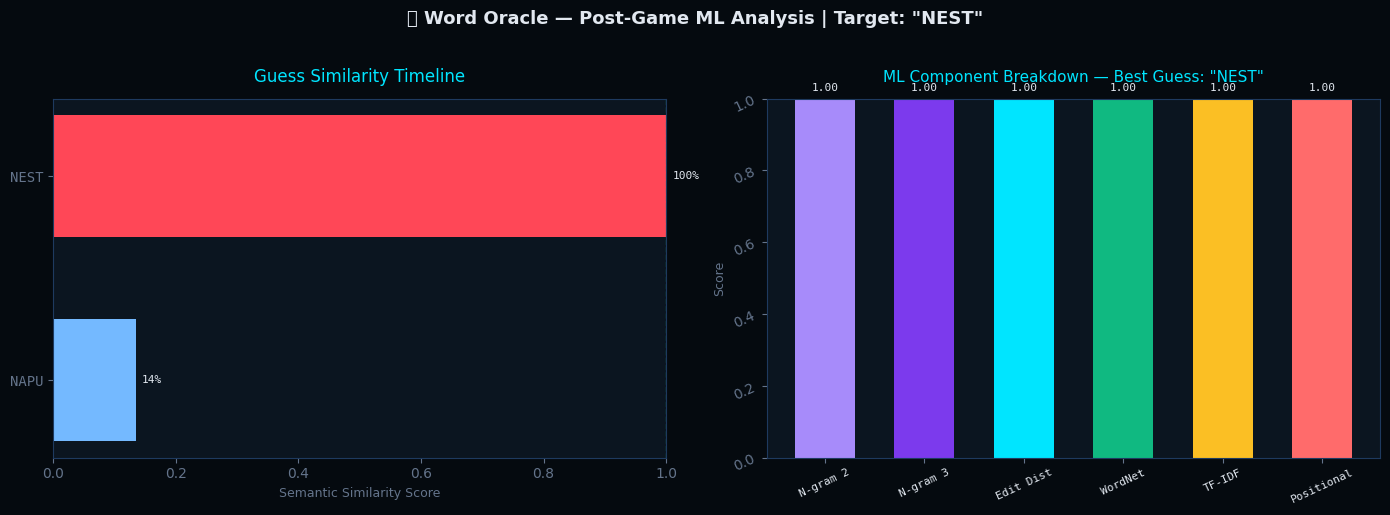

📊 Chart saved as word_oracle_analysis.png


In [26]:
# ─── VISUALIZATION: GUESS SIMILARITY RADAR ────────────────────────────────────
# Run this after playing to see a breakdown of your guesses

def plot_guess_radar():
    if not game.guess_hist:
        print('No guesses yet! Play the game first.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#050a0f')

    # ── Left: Similarity over guesses ──
    ax1 = axes[0]
    ax1.set_facecolor('#0b1520')
    sims = [h['sim'] for h in reversed(game.guess_hist)]
    words = [h['guess'][:8].upper() for h in reversed(game.guess_hist)]
    colors = [sim_color(s) for s in sims]
    bars = ax1.barh(range(len(sims)), sims, color=colors, edgecolor='none', height=0.6)
    ax1.set_yticks(range(len(words)))
    ax1.set_yticklabels(words, fontfamily='monospace', color='#e2e8f0', fontsize=10)
    ax1.set_xlim(0, 1)
    ax1.set_xlabel('Semantic Similarity Score', color='#64748b', fontsize=9)
    ax1.set_title('Guess Similarity Timeline', color='#00e5ff', fontsize=12, pad=12)
    ax1.tick_params(colors='#64748b')
    ax1.spines[:].set_color('#1e3a5f')
    ax1.axvline(x=1.0, color='#10b981', linewidth=1, linestyle='--', alpha=0.5)
    for i, (bar, sim) in enumerate(zip(bars, sims)):
        ax1.text(sim + 0.01, i, f'{sim:.0%}', va='center', color='#e2e8f0', fontsize=8, fontfamily='monospace')

    # ── Right: Component breakdown of best guess ──
    ax2 = axes[1]
    ax2.set_facecolor('#0b1520')
    best = max(game.guess_hist, key=lambda h: h['sim'])
    components = ['N-gram 2', 'N-gram 3', 'Edit Dist', 'WordNet', 'TF-IDF', 'Positional']
    keys       = ['ngram2',   'ngram3',   'edit',      'wordnet', 'tfidf',  'positional']
    vals = [best['scores'].get(k, 0) for k in keys]
    bar_colors = ['#a78bfa','#7c3aed','#00e5ff','#10b981','#fbbf24','#ff6b6b']
    bars2 = ax2.bar(components, vals, color=bar_colors, edgecolor='none', width=0.6)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Score', color='#64748b', fontsize=9)
    ax2.set_title(f'ML Component Breakdown — Best Guess: "{best["guess"].upper()}"', color='#00e5ff', fontsize=11, pad=12)
    ax2.tick_params(colors='#64748b', rotation=25)
    ax2.spines[:].set_color('#1e3a5f')
    for bar, val in zip(bars2, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                 ha='center', color='#e2e8f0', fontsize=8, fontfamily='monospace')
    plt.setp(ax2.get_xticklabels(), color='#e2e8f0', fontfamily='monospace', fontsize=8)

    plt.suptitle(f'🔮 Word Oracle — Post-Game ML Analysis | Target: "{game.word.upper()}"',
                 color='#e2e8f0', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('word_oracle_analysis.png', dpi=150, bbox_inches='tight',
                facecolor='#050a0f', edgecolor='none')
    plt.show()
    print('📊 Chart saved as word_oracle_analysis.png')

# Call this after playing:
plot_guess_radar()

## ML Visualization: Semantic Space Explorer

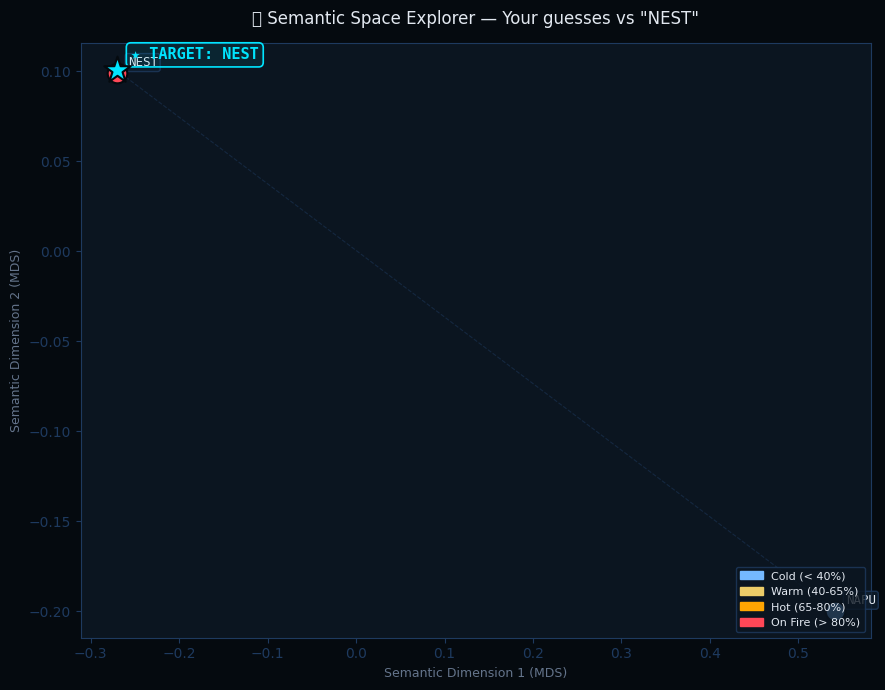

🧠 Semantic space chart saved as semantic_space.png


In [27]:
# ─── SEMANTIC SPACE: 2D SIMILARITY MAP ───────────────────────────────────────
# Plots your guesses in semantic space using MDS (multidimensional scaling)

from sklearn.manifold import MDS
from sklearn.preprocessing import MinMaxScaler

def plot_semantic_space():
    if len(game.guess_hist) < 2:
        print('Need at least 2 guesses for this visualization!')
        return

    words = [h['guess'] for h in game.guess_hist] + [game.word]
    n = len(words)

    # Build pairwise distance matrix
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                s = engine.score(words[i], words[j])['total']
                dist[i][j] = 1.0 - s

    # MDS to 2D
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=4)
    coords = mds.fit_transform(dist)

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('#050a0f')
    ax.set_facecolor('#0b1520')
    ax.spines[:].set_color('#1e3a5f')
    ax.tick_params(colors='#1e3a5f')

    # Guesses
    sims = [h['sim'] for h in game.guess_hist]
    for i, (word, coord) in enumerate(zip(words[:-1], coords[:-1])):
        clr = sim_color(sims[i])
        ax.scatter(coord[0], coord[1], c=clr, s=200, zorder=5, edgecolors='#050a0f', linewidth=1.5)
        ax.annotate(word.upper(), (coord[0], coord[1]),
                    textcoords='offset points', xytext=(8, 5),
                    color='#e2e8f0', fontsize=9, fontfamily='monospace',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#0f1e2e', edgecolor='#1e3a5f', alpha=0.8))

    # Target word
    tx, ty = coords[-1]
    ax.scatter(tx, ty, c='#00e5ff', s=400, zorder=10, marker='*',
               edgecolors='#050a0f', linewidth=1.5)
    ax.annotate(f'★ TARGET: {game.word.upper()}', (tx, ty),
                textcoords='offset points', xytext=(10, 8),
                color='#00e5ff', fontsize=11, fontfamily='monospace', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=(0.0, 0.898, 1.0, 0.08),
                          edgecolor='#00e5ff', linewidth=1.2))

    # Lines from each guess to target
    for i, coord in enumerate(coords[:-1]):
        ax.plot([coord[0], tx], [coord[1], ty], color='#1e3a5f', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.set_title(f'🧠 Semantic Space Explorer — Your guesses vs "{game.word.upper()}"',
                 color='#e2e8f0', fontsize=12, pad=14)
    ax.set_xlabel('Semantic Dimension 1 (MDS)', color='#64748b', fontsize=9)
    ax.set_ylabel('Semantic Dimension 2 (MDS)', color='#64748b', fontsize=9)

    # Legend
    legend_elems = [
        mpatches.Patch(color='#74b9ff', label='Cold (< 40%)'),
        mpatches.Patch(color='#eccc68', label='Warm (40-65%)'),
        mpatches.Patch(color='#ffa502', label='Hot (65-80%)'),
        mpatches.Patch(color='#ff4757', label='On Fire (> 80%)'),
    ]
    ax.legend(handles=legend_elems, loc='lower right',
              facecolor='#0b1520', edgecolor='#1e3a5f',
              labelcolor='#e2e8f0', fontsize=8)

    plt.tight_layout()
    plt.savefig('semantic_space.png', dpi=150, bbox_inches='tight',
                facecolor='#050a0f', edgecolor='none')
    plt.show()
    print('🧠 Semantic space chart saved as semantic_space.png')


plot_semantic_space()

## Quick Unit Tests

In [28]:
# ─── UNIT TESTS ───────────────────────────────────────────────────────────────

def run_tests():
    print('=' * 55)
    print('   WORD ORACLE — Unit Test Suite')
    print('=' * 55)
    passed = 0
    total  = 0

    def check(name, got, expected, op='eq'):
        nonlocal passed, total
        total += 1
        if op == 'eq':
            ok = got == expected
        elif op == 'gt':
            ok = got > expected
        elif op == 'lt':
            ok = got < expected
        elif op == 'gte':
            ok = got >= expected
        status = '✅ PASS' if ok else '❌ FAIL'
        if ok:
            passed += 1
        print(f'  {status}  {name} → got: {got}, expected: {expected} ({op})')

    # SemanticEngine tests
    print('\n🔬 SemanticEngine Tests')
    e = SemanticEngine()
    check('exact match score',    e.score('apple','apple')['total'],  1.0,  'eq')
    check('exact sets exact=True', e.score('apple','apple')['exact'], True, 'eq')
    check('unrelated words low', e.score('aardvark','zzz')['total'],  0.5, 'lt')
    check('similar words higher', e.score('ocean','sea')['total'],   0.0, 'gt')
    check('edit dist same word',  e._edit_distance_sim('cat','cat'),  1.0, 'eq')
    check('edit dist 1-char off', e._edit_distance_sim('cat','bat'),  0.0, 'gt')
    check('ngram overlap 2',      e._ngram_jaccard('hello','hello'),   1.0, 'eq')
    check('ngram diff words',     e._ngram_jaccard('abc','xyz'),       0.0, 'eq')

    # WordDB tests
    print('\n📚 WordDB Tests')
    check('easy words exist',   len(WORD_DB['easy'])   > 0, True, 'eq')
    check('medium words exist', len(WORD_DB['medium']) > 0, True, 'eq')
    check('hard words exist',   len(WORD_DB['hard'])   > 0, True, 'eq')
    check('all words have hint', all('hint' in w for pool in WORD_DB.values() for w in pool), True, 'eq')

    # AdaptiveDifficulty tests
    print('\n🤖 AdaptiveDifficulty Tests')
    ad = AdaptiveDifficulty()
    check('default diff', ad.current_diff, 'easy', 'eq')
    ad.record(True, 2, 10, 'easy')
    ad.record(True, 3, 12, 'easy')
    ad.record(True, 2, 8,  'easy')
    diff = ad.recommend_difficulty()
    check('bumps up after wins', diff in ['medium','hard'], True, 'eq')

    # ScoreKeeper tests
    print('\n🏆 ScoreKeeper Tests')
    sk = ScoreKeeper()
    pts = sk.calculate_score(3, 20.0, 'easy', 0, 1)
    check('score > 0',   pts, 0,   'gt')
    pts_hard = sk.calculate_score(2, 10.0, 'hard', 0, 0)
    pts_easy = sk.calculate_score(2, 10.0, 'easy', 0, 0)
    check('hard > easy score', pts_hard, pts_easy, 'gt')
    sk.add_result(True, 3, 20, 'easy', 0, 'apple')
    check('streak increments',  sk.streak,       1, 'eq')
    check('games played',       sk.games_played, 1, 'eq')
    check('games won',          sk.games_won,    1, 'eq')
    sk.add_result(False, 8, 60, 'easy', 2, 'flame')
    check('streak resets on loss', sk.streak, 0, 'eq')

    # Game engine tests
    print('\n🎮 GameEngine Tests')
    g = WordOracleGame()
    g.new_game()
    check('game active after start', g.active, True, 'eq')
    check('first letter revealed',   g.revealed[0], True, 'eq')
    result = g.make_guess(g.word)  # correct guess
    check('correct guess wins',  result.get('won'), True, 'eq')
    check('game inactive after win', g.active, False, 'eq')

    print('\n' + '=' * 55)
    print(f'   Results: {passed}/{total} tests passed ({passed/total:.0%})')
    print('=' * 55)

run_tests()

   WORD ORACLE — Unit Test Suite

🔬 SemanticEngine Tests
  ✅ PASS  exact match score → got: 1.0, expected: 1.0 (eq)
  ✅ PASS  exact sets exact=True → got: True, expected: True (eq)
  ✅ PASS  unrelated words low → got: 0.0, expected: 0.5 (lt)
  ✅ PASS  similar words higher → got: 0.4212, expected: 0.0 (gt)
  ✅ PASS  edit dist same word → got: 1.0, expected: 1.0 (eq)
  ✅ PASS  edit dist 1-char off → got: 0.6666666666666667, expected: 0.0 (gt)
  ✅ PASS  ngram overlap 2 → got: 1.0, expected: 1.0 (eq)
  ✅ PASS  ngram diff words → got: 0.0, expected: 0.0 (eq)

📚 WordDB Tests
  ✅ PASS  easy words exist → got: True, expected: True (eq)
  ✅ PASS  medium words exist → got: True, expected: True (eq)
  ✅ PASS  hard words exist → got: True, expected: True (eq)
  ✅ PASS  all words have hint → got: True, expected: True (eq)

🤖 AdaptiveDifficulty Tests
  ✅ PASS  default diff → got: easy, expected: easy (eq)
  ✅ PASS  bumps up after wins → got: True, expected: True (eq)

🏆 ScoreKeeper Tests
  ✅ PASS  s

---

## How to Play

1. **Run all cells** top to bottom (Cell 1 → Cell 8 to launch)
2. Choose a **game mode** from the dropdown: Classic, Hardcore (6 guesses), or Blitz
3. Enter your **name** and press **▶ New Game**
4. Type guesses in the text box and press **Enter** or **⚡ Guess**
5. Watch the **Semantic Similarity Meter** guide you closer to the target word
6. Use **💡 Hint** for an AI clue, **🔓 Reveal** to expose a random letter
7. After the game, run **Cell 9 & 10** for ML visualizations of your guesses
8. Press **🏆 Board** to see top scores, **📊 Stats** for AI-adapted difficulty

## ML Components Used

| Component | Library | Purpose |
|-----------|---------|----------|
| Character N-gram Jaccard | Pure Python | Surface-level string similarity |
| Levenshtein Edit Distance | Pure Python | Spelling distance measure |
| WordNet Path Similarity | `nltk` | Semantic conceptual closeness |
| TF-IDF Character Cosine | `scikit-learn` | Information-theoretic similarity |
| Multidimensional Scaling | `scikit-learn` | 2D semantic space visualization |
| Adaptive Difficulty | Custom ML logic | Adjusts to player performance |